### Fera formidável 4.5 - Um momento, por favor!

#### Enunciado

Objetivo: implemente o otimizador de Descida do Gradiente com Momento (Gradient
Descent with Momentum) na rede neural feita em Python puro.

Comentário: observe que o enunciado diz claramente que é para realizar a tarefa na
rede neural feita em Python puro nos vídeos da disciplina. Se você está usando o PyTorch,
numpy, tensorflow, keras, lightning ou qualquer outra biblioteca pronta, você está no
caminho errado!

### Introdução

O otmizador de Descida do Gradiente com Momento tem o intuito de acelerar a convergência de uma rede neural por meio da atualização dos parâmetros na direção oposta ao gradiente de erro. Isso é feito a partir de uma variável velocidade que acumula as atualizações das épocas anteriores, logo, se a rede estiver indo em uma mesma direção essas velociades serão aumentadas tornando a convergência mais rápida. 

A fórmula para a atualização dos pesos utilizando a Descida do Gradiente com Momento é dada por:

$$
v_t = \gamma v_{t-1} + \alpha \cdot \nabla J(\theta _t)
$$

$$
\theta _t = \theta _{t-1} - v_t
$$

Onde:

$v_t$ é a velocidade 

$\gamma$ é o coeficiente de momento

$\alpha$ é a taxa de aprendizado

$\nabla J(\theta _t)$ é o gradiente da perda em relação aos parâmetros $\theta _{t-1} - v_t$

$\theta _t$ são os parâmetros

A alteração feita no código da rede neural em python puro foi realizada apenas no loop de treinamento do modelo, a partir da criação do dicionário `velocidades` que armazena a velocidade para cada parâmetro da MLP antes do modelo começar a ser treinado. Dentro do loop, no momento que os parâmetros são atualizados, eles são atualizados utilizando a fórmula para Descida do Gradiente com Momento atualiando as velocidades do dicionário `velocidades`.

### Importando bibliotecas

In [103]:
import time
import seaborn as sns
import matplotlib.pyplot as plt
from classes import Valor, Neuronio, Camada, MLP
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### Definindo os datasets

In [104]:
df = sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [105]:
entradas = df.drop(columns= ["petal_width", "species"]).values
saidas = df["petal_width"].values.reshape(-1, 1)

### Dividindo os dados em treino e teste e aplicando a normalização padrão 

In [106]:
TAMANHO_TESTE = 0.1 

# Alocando 10% dos dados para teste
entradas_treino, entradas_teste, saidas_treino, saidas_teste = train_test_split(
    entradas, saidas, test_size=TAMANHO_TESTE)

In [107]:
normalizador = StandardScaler()
x_treino = normalizador.fit_transform(entradas_treino).tolist()
x_teste = normalizador.transform(entradas_teste).tolist()

saidas_treino_norm = normalizador.fit_transform(saidas_treino).tolist()
saidas_teste_norm = normalizador.transform(saidas_teste).tolist()

y_true = [j for i in saidas_treino_norm for j in i]
y_teste = [j for i in saidas_teste_norm for j in i]

### Treinando a MLP

In [108]:
NUM_DADOS_DE_ENTRADA = 3  
NUM_DADOS_DE_SAIDA = 1    
CAMADAS_OCULTAS = [3, 2]  

arquitetura_da_rede = CAMADAS_OCULTAS + [NUM_DADOS_DE_SAIDA]

minha_mlp = MLP(NUM_DADOS_DE_ENTRADA, arquitetura_da_rede)

In [109]:
NUM_EPOCAS = 300
TAXA_DE_APRENDIZADO = 0.001 # Resultado melhor do que 0.01
COEFICIENTE_DE_MOMENTO = 0.9

inicio = time.time()

velocidades = {} # Fera 4.5
for p in minha_mlp.parametros():
    velocidades[p] = 0
    
x_plot = []
y_plot = []

for epoca in range(NUM_EPOCAS):
    # forward pass
    y_pred = []
    for exemplo in x_treino:
        previsao = minha_mlp(exemplo, treino=True)
        y_pred.append(previsao)

    # loss
    erros = []
    for yt, yp in zip(y_true, y_pred):
        residuo = yp - yt
        erro_quadratico = residuo ** 2
        erros.append(erro_quadratico)        
    loss = sum(erros)

    # zero grad
    for p in minha_mlp.parametros():
        p.grad = 0

    # backpropagation
    loss.propagar_tudo()

    # atualiza parâmetros
    for p in minha_mlp.parametros(): 
        vel = velocidades[p] # Fera 4.5
        vel = COEFICIENTE_DE_MOMENTO * vel + TAXA_DE_APRENDIZADO * p.grad 
        p.data -= vel
        velocidades[p] = vel

    # mostra resultado (opcional)
    print(f"Época {epoca + 1:03d} — Perda Treino: {loss.data}")
    
    x_plot.append(epoca)
    y_plot.append(loss.data)
    
fim = time.time()
tempo = fim - inicio
print()
print(f"O código demorou {tempo/60:.2f} minutos para rodar")

Época 001 — Perda Treino: 159.65970565471557
Época 002 — Perda Treino: 158.29311669253565
Época 003 — Perda Treino: 155.87215041573825
Época 004 — Perda Treino: 152.8037423059363
Época 005 — Perda Treino: 149.5120996227319
Época 006 — Perda Treino: 146.3597723009366
Época 007 — Perda Treino: 143.59092403516672
Época 008 — Perda Treino: 141.31686715159162
Época 009 — Perda Treino: 139.54129540079194
Época 010 — Perda Treino: 138.20370436847946
Época 011 — Perda Treino: 137.2190587757064
Época 012 — Perda Treino: 136.50337954297416
Época 013 — Perda Treino: 135.98560747687355
Época 014 — Perda Treino: 135.6105062975694
Época 015 — Perda Treino: 135.33720355124726
Época 016 — Perda Treino: 135.13629344383375
Época 017 — Perda Treino: 134.98692737122516
Época 018 — Perda Treino: 134.87441016506523
Época 019 — Perda Treino: 134.78838518005634
Época 020 — Perda Treino: 134.72152715429036
Época 021 — Perda Treino: 134.66862410378502
Época 022 — Perda Treino: 134.62594033851292
Época 023 — Per

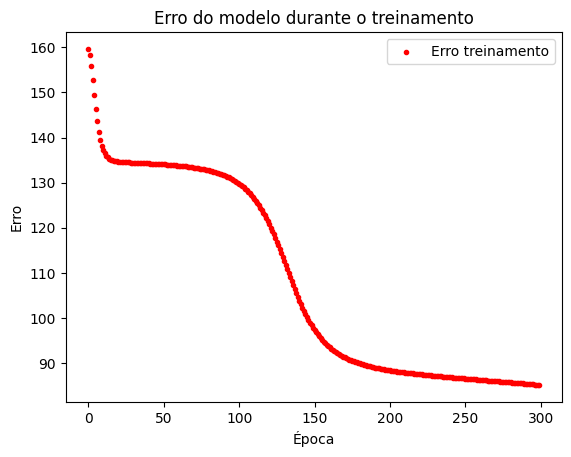

In [110]:
plt.scatter(x_plot, y_plot, color= "red", label= "Erro treinamento", marker= ".")
plt.title("Erro do modelo durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend()

O gráfico mostra o compormento da rede neural com o otimizador de descida do gradiente caracterizado por convergir rápido a um mínimo.

### Conclusão 

O modelo funcinou bem em aplicar a descida do gradiente com momento e a aplicação dele foi simples, mostrando a eficiência desse otimizador. Além disso, foi interessante perceber o quão diferente é o comportamento do erro durante o treinamento do modelo, que chega rapidamente a um mínimo e se mantem relativamente constante até chegar em outro mínimo, formando uma espécie de escada.

### Referências

INDURAJ. Different Variants of gradient descent. Disponível em: <https://induraj2020.medium.com/different-variants-of-gradient-descent-6854d3118c4c>.

DSA, E. Capítulo 12 - Aprendizado Com a Descida do Gradiente. Disponível em: <https://www.deeplearningbook.com.br/aprendizado-com-a-descida-do-gradiente/>.

WIKIPEDIA CONTRIBUTORS. Gradient descent. Disponível em: <https://en.wikipedia.org/wiki/Gradient_descent>.